In [43]:
import pandas as pd
import numpy as np


In [44]:
beml_df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/BEML.csv')
beml_df[0:5]

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1121.0,1151.00,1121.00,1134.0,1135.60,101651.0,1157.18
1,2010-01-05,1146.8,1149.00,1128.75,1135.0,1134.60,59504.0,676.47
2,2010-01-06,1140.0,1164.25,1130.05,1137.0,1139.60,128908.0,1482.84
3,2010-01-07,1142.0,1159.40,1119.20,1141.0,1144.15,117871.0,1352.98
4,2010-01-08,1156.0,1172.00,1140.00,1141.2,1144.05,170063.0,1971.42


In [45]:
glaxo_df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/GLAXO.csv')
glaxo_df[0:5]

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1613.00,1629.10,1602.00,1629.0,1625.65,9365.0,151.74
1,2010-01-05,1639.95,1639.95,1611.05,1620.0,1616.80,38148.0,622.58
2,2010-01-06,1618.00,1644.00,1617.00,1639.0,1638.50,36519.0,595.09
3,2010-01-07,1645.00,1654.00,1636.00,1648.0,1648.70,12809.0,211.00
4,2010-01-08,1650.00,1650.00,1626.55,1640.0,1639.80,28035.0,459.11


In [46]:
beml_df = beml_df[['Date','Close']]
glaxo_df = glaxo_df[['Date','Close']]

In [47]:
beml_df

,Date,Close
0,2010-01-04,1135.60
1,2010-01-05,1134.60
2,2010-01-06,1139.60
3,2010-01-07,1144.15
4,2010-01-08,1144.05
...,...,...
1734,2016-12-26,950.25
1735,2016-12-27,975.70
1736,2016-12-28,974.40
1737,2016-12-29,986.05


In [48]:
# making data as index with the help of DatetimeIndex function int pandas which makes the text Date to useable date and 
# sort the data in df with data(index) in assending order 

glaxo_df = glaxo_df.set_index(pd.DatetimeIndex(glaxo_df['Date']))
beml_df = beml_df.set_index(pd.DatetimeIndex(beml_df['Date']))

Text(0, 0.5, 'Close Price')

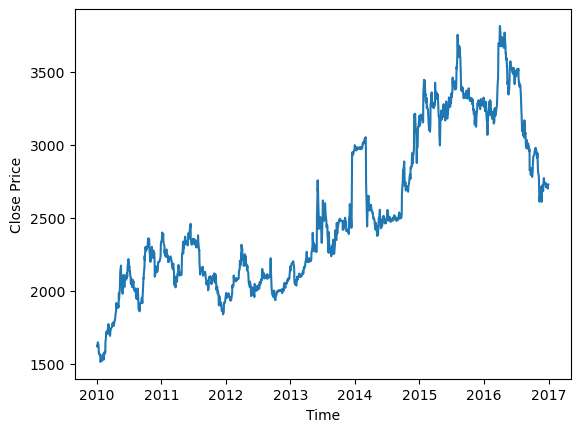

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(glaxo_df['Close'])
plt.xlabel('Time')
plt.ylabel('Close Price')

Text(0, 0.5, 'Close Price')

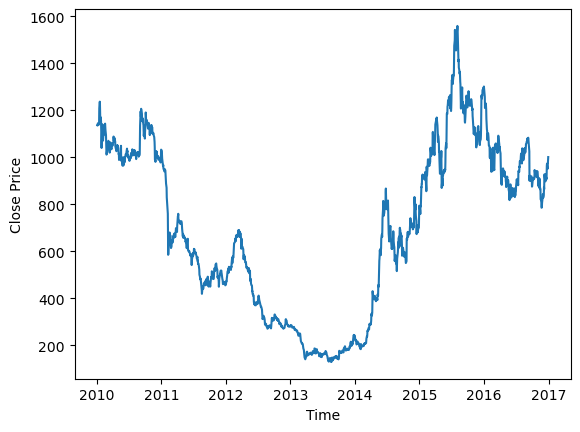

In [50]:
plt.plot(beml_df['Close'])
plt.xlabel('Time')
plt.ylabel('Close Price')

In [57]:
# pct_change cal the precentage change of the value in the row and the previos row if periods=1 
# if periods=2 it cal the for the 2nd previous row value
# here we cal the pct_change of close price form todays price to prev day price by using this fun
# create new col gain and add those val in col to df
glaxo_df['gain'] = glaxo_df.Close.pct_change(periods=1)
beml_df['gain'] = beml_df.Close.pct_change(periods=1)

In [61]:
# for the first row there is no prev row to cal the pct_change it gives Na so we drop it
glaxo_df = glaxo_df.dropna()
beml_df = beml_df.dropna()
        

Text(0.5, 1.0, 'gainsvstime')

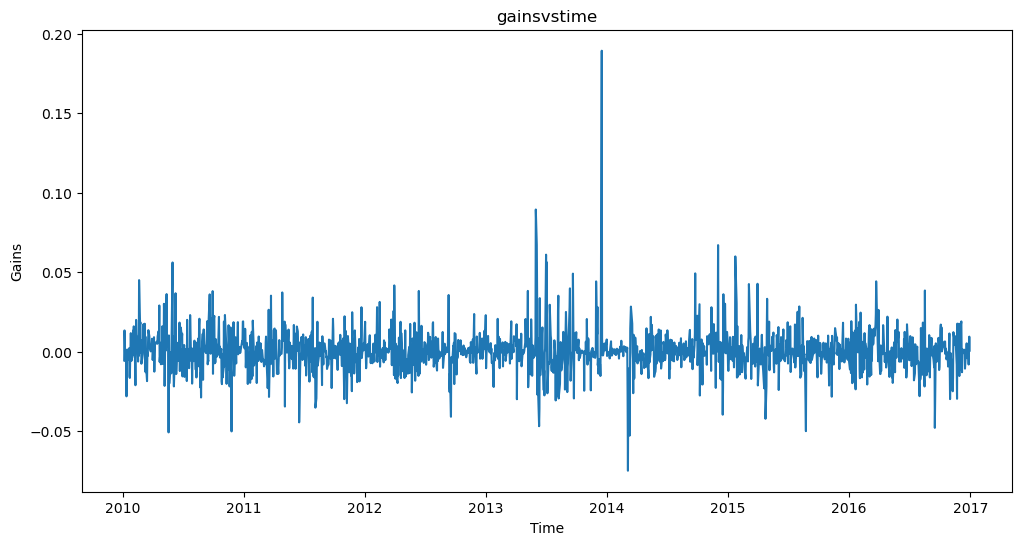

In [68]:
#ploting the gains
plt.figure(figsize=(12,6));
plt.plot(glaxo_df.index,glaxo_df['gain']);
plt.xlabel('Time');
plt.ylabel('Gains');
plt.title('gainsvstime')



Text(0.5, 1.0, 'gainsvstime')

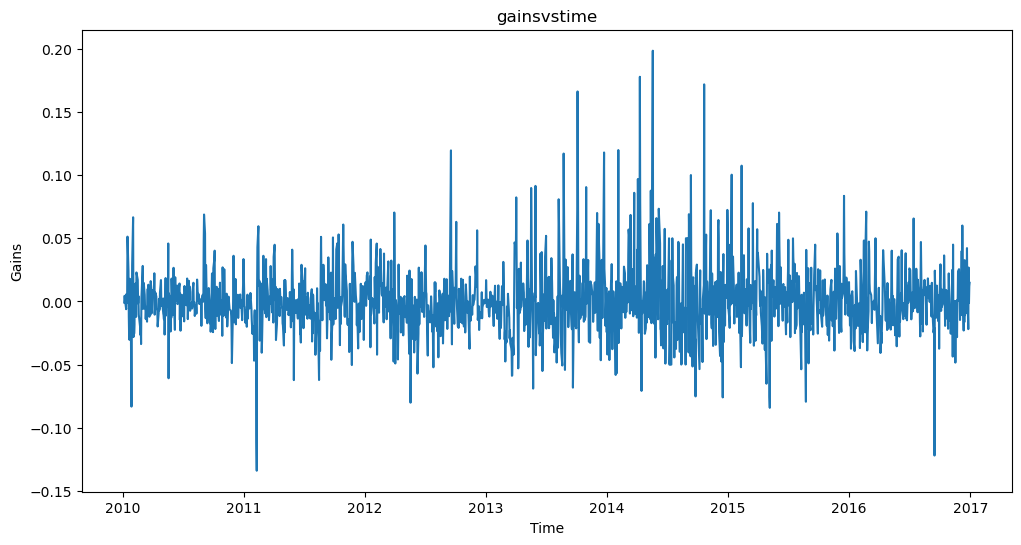

In [67]:
plt.figure(figsize=(12,6));
plt.plot(beml_df.index,beml_df['gain']);
plt.xlabel('Time');
plt.ylabel('Gains');
plt.title('gainsvstime')

/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_12129/3978639092.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(glaxo_df.gain,label = 'glaxo')


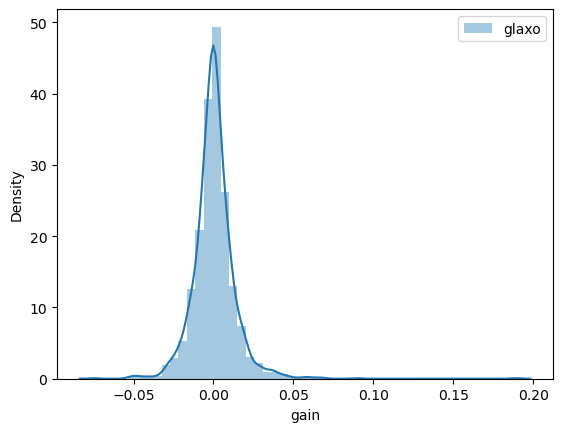

In [75]:
#ploting dist plot (hist)
sns.distplot(glaxo_df.gain,label = 'glaxo')
plt.xlabel('gain');
plt.ylabel('Density');
plt.legend();

/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_12129/166851172.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(beml_df.gain,label = 'beml')


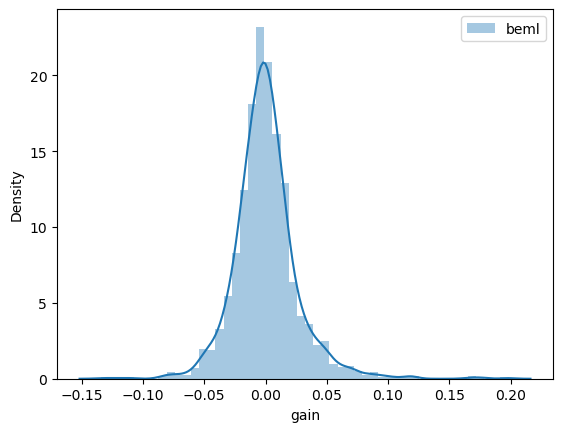

In [76]:
#ploting dist plot (hist)
sns.distplot(beml_df.gain,label = 'beml')
plt.xlabel('gain');
plt.ylabel('Density');
plt.legend();

In [80]:
print('Mean :' , glaxo_df.gain.mean())
print('Mean : ' , round(glaxo_df.gain.mean() , 5))
print('standard deviation :' , glaxo_df.gain.std())
print('standard deviantion : ' , round(glaxo_df.gain.std() , 5))

Mean : 0.0003860410825922916
Mean :  0.00039
standard deviation : 0.013360538552253333
standard deviantion :  0.01336


In [83]:
print('Mean : ' , round(beml_df.gain.mean() , 4))
print('standard deviantion : ' , round(beml_df.gain.std() , 4))

Mean :  0.0003
standard deviantion :  0.0264


In [91]:
from scipy import stats
# scipy which means scientific python
# stats = statictics
# norm = normal distribution
# cdf = cummulative distibution function
# finding the popbability of making 2% loss or higher in glaxo
stats.norm.cdf(-0.02,
               loc = glaxo_df.gain.mean(),
               scale = glaxo_df.gain.std()
              )

np.float64(0.06352488667177396)

In [87]:
# finding the popbability of making 2% gain or higher in glaxo
1-stats.norm.cdf(0.02,
               loc = glaxo_df.gain.mean(),
               scale = glaxo_df.gain.std()
              )

np.float64(0.07104511457618568)

In [90]:
# finding the popbability of making 2% loss or higher in beml
x=stats.norm.cdf(-0.02,
               loc = beml_df.gain.mean(),
               scale = beml_df.gain.std()
              )
# finding the popbability of making 2% gain or higher in beml
y=1-stats.norm.cdf(0.02,
               loc = beml_df.gain.mean(),
               scale = beml_df.gain.std()
              )
print('making 2% loss or higher : ',x)
print('making 2% gain or higher : ',y)

making 2% loss or higher :  0.22155987503755292
making 2% gain or higher :  0.22769829484075355
